Follow-up on the market volatility and long term investing analysis with an analysis of the sensitivity of the results to the volatility of the index. Given the finding that consistent investing benefits from market volatility is there any point at which this finding breaks down? Is there any level of volatility or return that is not better off on average than a "market" with 0% volatility?



In [19]:
# import necessary libraries
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import datetime as dt

from scipy import stats
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

from functions import simulate_index_paths, calculate_terminal_values

In [20]:
# Set universal plot styling parameters
AXES_FONT_SIZE = 16
TICK_FONT_SIZE = 12
TITLE_FONT_SIZE = 20
LEGEND_FONT_SIZE = 14
NOTE_FONT_SIZE = 16
PRIMARY_LINE_WIDTH = 2.5
SECONDARY_LINE_WIDTH = 1.2

In [21]:
# Set universal input parameters
INDEX_START_VALUE = 1000
ACCUMULATION_LENGTH = 30 # years
ANNUAL_RATE_OF_RETURN = 0.08
ANNUAL_VOLATILITY = 0.15
NUM_PATHS = 1000

SIM_SEED = 42

MONTHLY_CONTRIBUTION = 1800

In [23]:
# input parameters
annual_volatility = np.arange(0.01, 0.50, 0.01)  # Example: testing multiple volatilities

accumulation_lengths = []
annual_rate_of_returns = []
annual_volatilities = []
num_pathses = []
sim_seeds = []
monthly_contributions = []
beat_rates = []

example_paths = []

for vol in annual_volatility:
    sim_paths = simulate_index_paths(INDEX_START_VALUE, ACCUMULATION_LENGTH, ANNUAL_RATE_OF_RETURN, vol, NUM_PATHS, SIM_SEED)
    example_paths.append(sim_paths['Path_42'])  # Store example paths for later plotting
    
    #   plot_simulation_results(sim_paths, ACCUMULATION_LENGTH, NUM_PATHS)
    terminal_values_summary = calculate_terminal_values(sim_paths, ANNUAL_RATE_OF_RETURN, MONTHLY_CONTRIBUTION)

    beat_rate = (sum(tv > terminal_values_summary.loc[terminal_values_summary['Path'] == 'Steady Growth', 'Terminal Value'].values[0] for tv in terminal_values_summary.loc[terminal_values_summary['Path'] != 'Steady Growth', 'Terminal Value'].values) / NUM_PATHS) * 100

    accumulation_lengths.append(ACCUMULATION_LENGTH)
    annual_rate_of_returns.append(ANNUAL_RATE_OF_RETURN)
    annual_volatilities.append(vol)
    num_pathses.append(NUM_PATHS)
    sim_seeds.append(SIM_SEED)
    monthly_contributions.append(MONTHLY_CONTRIBUTION)
    beat_rates.append(beat_rate)

results_df = pd.DataFrame({
    'Accumulation Length (Years)': accumulation_lengths,
    'Annual Rate of Return': annual_rate_of_returns,
    'Annual Volatility': annual_volatilities,
    'Number of Paths': num_pathses,
    'Simulation Seed': sim_seeds,
    'Monthly Contribution': monthly_contributions,
    'Percentage Beating Steady Growth (%)': beat_rates
})

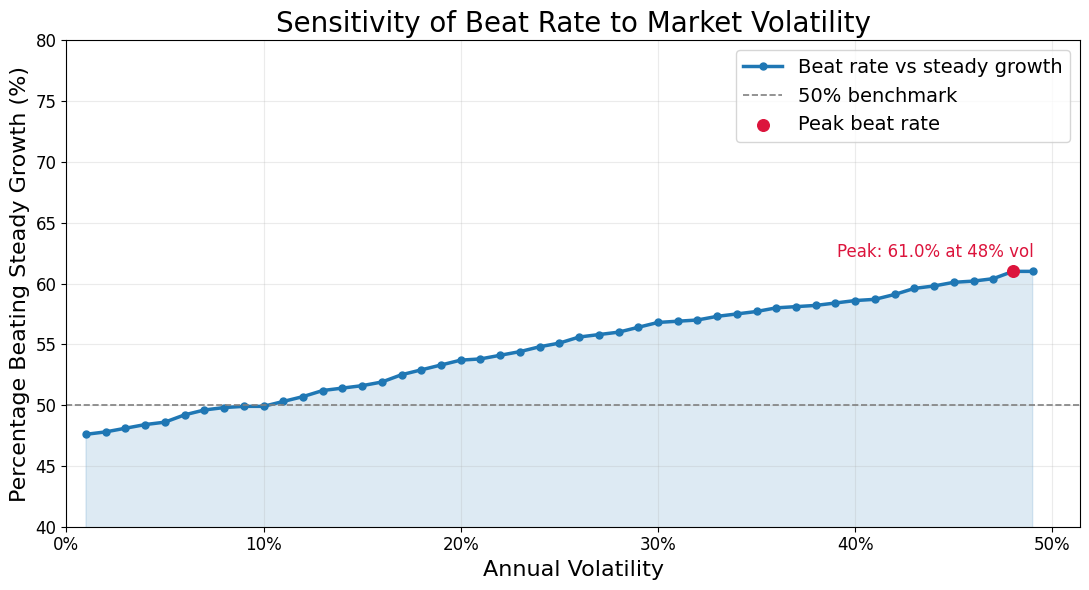

In [38]:
# Chart: how beat rate changes with annual volatility
plot_df = results_df.sort_values('Annual Volatility').copy()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    plot_df['Annual Volatility'],
    plot_df['Percentage Beating Steady Growth (%)'],
    color='tab:blue',
    marker='o',
    linewidth=PRIMARY_LINE_WIDTH,
    markersize=5,
    label='Beat rate vs steady growth'
 )

ax.fill_between(
    plot_df['Annual Volatility'],
    plot_df['Percentage Beating Steady Growth (%)'],
    alpha=0.15,
    color='tab:blue'
 )

# Reference line for 50% threshold
ax.axhline(50, color='gray', linestyle='--', linewidth=SECONDARY_LINE_WIDTH, label='50% benchmark')

# Highlight the maximum beat rate point
max_idx = plot_df['Percentage Beating Steady Growth (%)'].idxmax()
x_max = plot_df.loc[max_idx, 'Annual Volatility']
y_max = plot_df.loc[max_idx, 'Percentage Beating Steady Growth (%)']

ax.scatter([x_max], [y_max], color='crimson', s=70, zorder=5, label='Peak beat rate')
ax.annotate(
    f"Peak: {y_max:.1f}% at {x_max:.0%} vol",
    xy=(.38, y_max),
    xytext=(15, 10),
    textcoords='offset points',
    fontsize=TICK_FONT_SIZE,
    color='crimson'
 )

ax.set_title('Sensitivity of Beat Rate to Market Volatility', fontsize=TITLE_FONT_SIZE)
ax.set_xlabel('Annual Volatility', fontsize=AXES_FONT_SIZE)
ax.set_ylabel('Percentage Beating Steady Growth (%)', fontsize=AXES_FONT_SIZE)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_ylim(40, 80)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=LEGEND_FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
plt.tight_layout()
plt.show()

In [29]:
# Build a DataFrame from example_paths (each column = Path_42 at a given volatility)
example_paths_df = pd.concat(example_paths, axis=1)
example_paths_df.columns = [f"{v:.0%}" for v in annual_volatility]
example_paths_df.index.name = "Month"

# 3D surface arrays: Month (x), Volatility (y), Path_42 Index Value (z)
months = example_paths_df.index.to_numpy()
vols = annual_volatility  # numeric (0.01 ... 0.49)
X, Y = np.meshgrid(months, vols)
Z = example_paths_df.T.to_numpy()

# Interactive 3D chart with Plotly
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale="Viridis",
            colorbar=dict(title="Index Value"),
            hovertemplate="Month: %{x}<br>Vol: %{y:.0%}<br>Index: %{z:,.0f}<extra></extra>",
        )
    ]
)

fig.update_layout(
    title="Interactive 3D Surface: Path_42 Across Volatility Levels",
    scene=dict(
        xaxis_title="Month",
        yaxis_title="Annual Volatility",
        zaxis_title="Index Value",
        yaxis_tickformat=".0%",
    ),
    width=1000,
    height=650,
    margin=dict(l=0, r=0, t=40, b=0),
)

# Fallback renderer in case VS Code mime rendering cache is stale
try:
    fig.show()
except ValueError as e:
    if "nbformat" in str(e):
        fig.show(renderer="browser")
    else:
        raise

In [30]:
# input parameters
annual_volatility = np.arange(0.01, 0.50, 0.01)  # Example: testing multiple volatilities

accumulation_lengths = []
annual_rate_of_returns = []
annual_volatilities = []
num_pathses = []
sim_seeds = []
monthly_contributions = []
beat_rates = []

example_paths_random_seed = []

for vol in annual_volatility:
    sim_seed = np.random.randint(0, 100000)  # Generate a new random seed for each volatility level
    sim_paths = simulate_index_paths(INDEX_START_VALUE, ACCUMULATION_LENGTH, ANNUAL_RATE_OF_RETURN, vol, NUM_PATHS, sim_seed)
    example_paths_random_seed.append(sim_paths['Path_42'])  # Store example paths for later plotting
    
    #   plot_simulation_results(sim_paths, ACCUMULATION_LENGTH, NUM_PATHS)
    terminal_values_summary = calculate_terminal_values(sim_paths, ANNUAL_RATE_OF_RETURN, MONTHLY_CONTRIBUTION)

    beat_rate = (sum(tv > terminal_values_summary.loc[terminal_values_summary['Path'] == 'Steady Growth', 'Terminal Value'].values[0] for tv in terminal_values_summary.loc[terminal_values_summary['Path'] != 'Steady Growth', 'Terminal Value'].values) / NUM_PATHS) * 100

    accumulation_lengths.append(ACCUMULATION_LENGTH)
    annual_rate_of_returns.append(ANNUAL_RATE_OF_RETURN)
    annual_volatilities.append(vol)
    num_pathses.append(NUM_PATHS)
    sim_seeds.append(sim_seed)
    monthly_contributions.append(MONTHLY_CONTRIBUTION)
    beat_rates.append(beat_rate)

results_df_random_seed = pd.DataFrame({
    'Accumulation Length (Years)': accumulation_lengths,
    'Annual Rate of Return': annual_rate_of_returns,
    'Annual Volatility': annual_volatilities,
    'Number of Paths': num_pathses,
    'Simulation Seed': sim_seeds,
    'Monthly Contribution': monthly_contributions,
    'Percentage Beating Steady Growth (%)': beat_rates
})

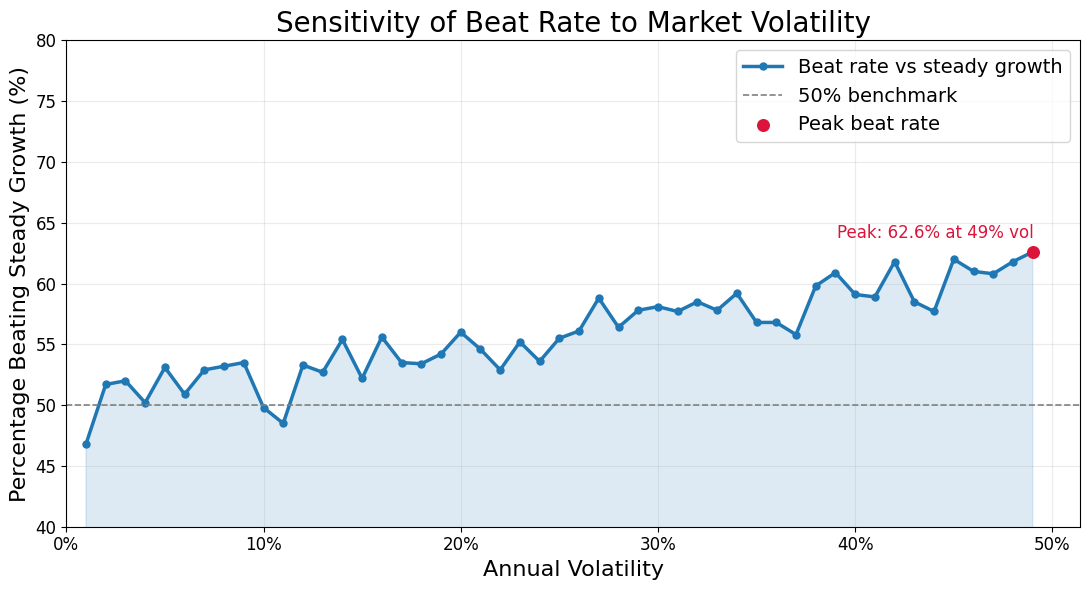

In [40]:
# Chart: how beat rate changes with annual volatility
plot_df = results_df_random_seed.sort_values('Annual Volatility').copy()

fig, ax = plt.subplots(figsize=(11, 6))

ax.plot(
    plot_df['Annual Volatility'],
    plot_df['Percentage Beating Steady Growth (%)'],
    color='tab:blue',
    marker='o',
    linewidth=PRIMARY_LINE_WIDTH,
    markersize=5,
    label='Beat rate vs steady growth'
 )

ax.fill_between(
    plot_df['Annual Volatility'],
    plot_df['Percentage Beating Steady Growth (%)'],
    alpha=0.15,
    color='tab:blue'
 )

# Reference line for 50% threshold
ax.axhline(50, color='gray', linestyle='--', linewidth=SECONDARY_LINE_WIDTH, label='50% benchmark')

# Highlight the maximum beat rate point
max_idx = plot_df['Percentage Beating Steady Growth (%)'].idxmax()
x_max = plot_df.loc[max_idx, 'Annual Volatility']
y_max = plot_df.loc[max_idx, 'Percentage Beating Steady Growth (%)']

ax.scatter([x_max], [y_max], color='crimson', s=70, zorder=5, label='Peak beat rate')
ax.annotate(
    f"Peak: {y_max:.1f}% at {x_max:.0%} vol",
    xy=(.38, y_max),
    xytext=(15, 10),
    textcoords='offset points',
    fontsize=TICK_FONT_SIZE,
    color='crimson'
 )

ax.set_title('Sensitivity of Beat Rate to Market Volatility', fontsize=TITLE_FONT_SIZE)
ax.set_xlabel('Annual Volatility', fontsize=AXES_FONT_SIZE)
ax.set_ylabel('Percentage Beating Steady Growth (%)', fontsize=AXES_FONT_SIZE)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_ylim(40, 80)
ax.set_xlim(left=0)
ax.grid(True, alpha=0.25)
ax.legend(fontsize=LEGEND_FONT_SIZE)
ax.tick_params(axis='both', which='major', labelsize=TICK_FONT_SIZE)
plt.tight_layout()
plt.show()

In [33]:
# Build a DataFrame from example_paths (each column = Path_42 at a given volatility)
example_paths_random_seed_df = pd.concat(example_paths_random_seed, axis=1)
example_paths_random_seed_df.columns = [f"{v:.0%}" for v in annual_volatility]
example_paths_random_seed_df.index.name = "Month"

# 3D surface arrays: Month (x), Volatility (y), Path_42 Index Value (z)
months = example_paths_random_seed_df.index.to_numpy()
vols = annual_volatility  # numeric (0.01 ... 0.49)
X, Y = np.meshgrid(months, vols)
Z = example_paths_random_seed_df.T.to_numpy()

# Interactive 3D chart with Plotly
import plotly.graph_objects as go

fig = go.Figure(
    data=[
        go.Surface(
            x=X,
            y=Y,
            z=Z,
            colorscale="Viridis",
            colorbar=dict(title="Index Value"),
            hovertemplate="Month: %{x}<br>Vol: %{y:.0%}<br>Index: %{z:,.0f}<extra></extra>",
        )
    ]
)

fig.update_layout(
    title="Interactive 3D Surface: Path_42 Across Volatility Levels",
    scene=dict(
        xaxis_title="Month",
        yaxis_title="Annual Volatility",
        zaxis_title="Index Value",
        yaxis_tickformat=".0%",
    ),
    width=1000,
    height=650,
    margin=dict(l=0, r=0, t=40, b=0),
)

# Fallback renderer in case VS Code mime rendering cache is stale
try:
    fig.show()
except ValueError as e:
    if "nbformat" in str(e):
        fig.show(renderer="browser")
    else:
        raise